<a href="https://colab.research.google.com/github/jesusfunez108-png/Estadistica_G1_2026_1/blob/main/1_SEMANA_1_Regresiones_Lineales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Debido a la situación que atravesó la Universidad, se han planeado, para tres semanas, seis Notebook para cubrir los temas de Regresiones y Series de Tiempo.

Para ello se dedica la primera sesión exclusivamente a asentar las bases de la regresión lineal (simple y múltiple) con el contraste visual de Anscombe con el objeto de dejar a los estudiantes de ingeniería con una intuición muy clara sobre por qué no deben confiar solo en los números.

A continuación, se presenta la estructura completa del **Notebook 1**.

# Sesión 1: Regresión Lineal Simple y Múltiple

**Asignatura:** Estadística Aplicada con Python y R

**Objetivos de la sesión:**

1. Comprender la importancia de la visualización de datos en el modelado estadístico utilizando el Cuarteto de Anscombe.
2. Ajustar e interpretar modelos de regresión lineal simple y múltiple usando las bibliotecas `seaborn` y `statsmodels`.
3. Interpretar la salida estadística del modelo (similar a la función `summary()` en R).

El Cuarteto de Anscombe es un conjunto de cuatro grupos de datos que, a pesar de tener estadísticas descriptivas (como la media, varianza y coeficiente de correlación) casi idénticas, presentan distribuciones visuales muy diferentes. Sirve para ilustrar la importancia de la visualización de datos antes de realizar un análisis estadístico, demostrando que los resúmenes numéricos pueden ser engañosos.

In [ ]:
# Importación de las librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Configuración de estilo visual para los gráficos
sns.set_theme(style="whitegrid")

El código en la celda `30VXAX18kXi7` tiene dos propósitos principales:

1.  **Importación de librerías:** Se importan cuatro librerías fundamentales para el análisis de datos y la visualización en Python:
    *   **`import pandas as pd`**: Importa la librería Pandas, que es esencial para trabajar con estructuras de datos tabulares (como DataFrames) de manera eficiente. Permite cargar, manipular, limpiar y analizar datos.
    *   **`import seaborn as sns`**: Importa Seaborn, una librería de visualización de datos que se basa en Matplotlib. Seaborn proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. Es especialmente útil para explorar relaciones entre variables.
    *   **`import matplotlib.pyplot as plt`**: Importa Matplotlib, la librería de graficación más popular en Python. `pyplot` es un módulo de Matplotlib que proporciona una interfaz similar a MATLAB para crear gráficos de manera sencilla. A menudo se usa junto con Seaborn para personalizar aún más los gráficos.
    *   **`import statsmodels.formula.api as smf`**: Importa un módulo específico de Statsmodels. Statsmodels es una librería para estimación de modelos estadísticos y pruebas estadísticas. El submódulo `formula.api` permite definir modelos usando una sintaxis similar a las fórmulas de R, lo que facilita la especificación de regresiones y otros modelos.

2.  **Configuración de estilo visual:**
    *   **`sns.set_theme(style="whitegrid")`**: Esta línea utiliza una función de Seaborn para establecer un estilo visual predeterminado para todos los gráficos que se generen posteriormente. En este caso, `"whitegrid"` aplica un tema con un fondo blanco y una cuadrícula, lo que mejora la legibilidad de los gráficos. Esto ayuda a que los gráficos se vean más profesionales y consistentes.

# 1. El Cuarteto de Anscombe: ¿Por qué debemos graficar los datos?

El Cuarteto de Anscombe está compuesto por cuatro conjuntos de datos que tienen propiedades estadísticas descriptivas casi idénticas (media, varianza, correlación y línea de regresión), pero que al graficarse muestran distribuciones completamente diferentes.

El modelo de regresión lineal simple se define mediante la ecuación:


$$y = \beta_0 + \beta_1 x + \epsilon$$

Vamos a cargar el conjunto de datos y observar sus estadísticas resumidas.

In [ ]:
import seaborn as sns
import pandas as pd

# mostrar todos los datasets de seaborn
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
# Mostrar el dataset el cuarteto de anscombe
import seaborn as sns
anscombe = sns.load_dataset("anscombe")
print(anscombe)

   dataset     x      y
0        I  10.0   8.04
1        I   8.0   6.95
2        I  13.0   7.58
3        I   9.0   8.81
4        I  11.0   8.33
5        I  14.0   9.96
6        I   6.0   7.24
7        I   4.0   4.26
8        I  12.0  10.84
9        I   7.0   4.82
10       I   5.0   5.68
11      II  10.0   9.14
12      II   8.0   8.14
13      II  13.0   8.74
14      II   9.0   8.77
15      II  11.0   9.26
16      II  14.0   8.10
17      II   6.0   6.13
18      II   4.0   3.10
19      II  12.0   9.13
20      II   7.0   7.26
21      II   5.0   4.74
22     III  10.0   7.46
23     III   8.0   6.77
24     III  13.0  12.74
25     III   9.0   7.11
26     III  11.0   7.81
27     III  14.0   8.84
28     III   6.0   6.08
29     III   4.0   5.39
30     III  12.0   8.15
31     III   7.0   6.42
32     III   5.0   5.73
33      IV   8.0   6.58
34      IV   8.0   5.76
35      IV   8.0   7.71
36      IV   8.0   8.84
37      IV   8.0   8.47
38      IV   8.0   7.04
39      IV   8.0   5.25
40      IV  19.0

In [ ]:
import seaborn as sns
import pandas as pd

# Cargar el dataset directamente desde seaborn
anscombe = sns.load_dataset("anscombe")

# Mostrar las estadísticas descriptivas agrupadas por cada dataset (I, II, III, IV)
resumen = anscombe.groupby("dataset").agg(['mean', 'var'])
print("Estadísticas Descriptivas (Media y Varianza):")
print(resumen)

Estadísticas Descriptivas (Media y Varianza):
           x               y          
        mean   var      mean       var
dataset                               
I        9.0  11.0  7.500909  4.127269
II       9.0  11.0  7.500909  4.127629
III      9.0  11.0  7.500000  4.122620
IV       9.0  11.0  7.500909  4.123249


Como podemos observar, estadísticamente los cuatro grupos parecen idénticos. Ahora vamos a utilizar `seaborn` para ajustar una regresión lineal visual a cada uno de los cuatro conjuntos de datos. `lmplot` nos permite graficar la dispersión y la línea de mejor ajuste simultáneamente.

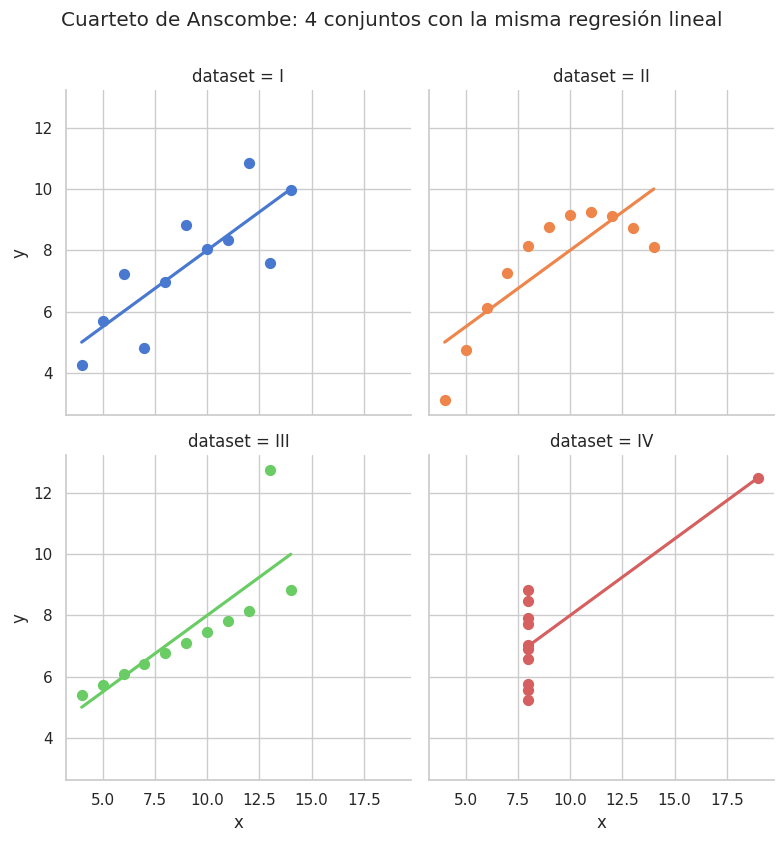

In [ ]:
import seaborn as sns

# Visualización de las regresiones con seaborn
sns.lmplot(
    data=anscombe,
    x="x",
    y="y",
    col="dataset",
    hue="dataset",
    col_wrap=2,
    ci=None,
    palette="muted",
    height=4,
    scatter_kws={"s": 50, "alpha": 1}
)
plt.suptitle("Cuarteto de Anscombe: 4 conjuntos con la misma regresión lineal", y=1.05)
plt.show()

El código en la celda `kECzZgphkXi9` se dedica a visualizar el Cuarteto de Anscombe utilizando la función `sns.lmplot` de Seaborn, que es ideal para graficar relaciones lineales y sus regresiones.

**Explicación del código:**

*   **`import seaborn as sns`**: Se importa la librería Seaborn, aunque ya se había importado al inicio del notebook, se incluye aquí por si esta celda se ejecutara de forma independiente.

*   **`sns.lmplot(...)`**: Esta es la función principal que crea el gráfico de dispersión con una línea de regresión lineal. Sus parámetros son:
    *   **`data=anscombe`**: Indica que el DataFrame `anscombe` es la fuente de los datos.
    *   **`x="x"`**: Define la columna `x` del DataFrame como la variable independiente (eje X).
    *   **`y="y"`**: Define la columna `y` del DataFrame como la variable dependiente (eje Y).
    *   **`col="dataset"`**: Es crucial para el Cuarteto de Anscombe. Crea una cuadrícula de gráficos, donde cada columna (o "col") representa un valor único de la columna `dataset` (es decir, I, II, III, IV).
    *   **`hue="dataset"`**: Asigna un color diferente a los puntos de datos y a la línea de regresión para cada `dataset`, mejorando la distinción visual.
    *   **`col_wrap=2`**: Organiza los gráficos de la cuadrícula en dos columnas. Esto significa que habrá dos gráficos en la primera fila y dos en la segunda, facilitando la comparación.
    *   **`ci=None`**: Desactiva la visualización del intervalo de confianza alrededor de la línea de regresión. Esto se hace para enfocar la atención únicamente en la línea de mejor ajuste.
    *   **`palette="muted"`**: Establece la paleta de colores a utilizar para diferenciar los `dataset`s.
    *   **`height=4`**: Define la altura de cada subgráfico en la cuadrícula.
    *   **`scatter_kws={"s": 50, "alpha": 1}`**: Son argumentos pasados directamente a la función que dibuja los puntos de dispersión (`scatter`).
        *   `"s": 50`: Aumenta el tamaño de los puntos a 50.
        *   `"alpha": 1`: Hace que los puntos sean completamente opacos (sin transparencia).

*   **`plt.suptitle("Cuarteto de Anscombe: 4 conjuntos con la misma regresión lineal", y=1.05)`**: Añade un título principal a toda la figura (que contiene los cuatro subgráficos). El parámetro `y=1.05` ajusta la posición vertical del título para que no se solape con los gráficos.

*   **`plt.show()`**: Muestra la figura generada con todos los gráficos. Es una buena práctica usarla explícitamente cuando se trabaja con Matplotlib para asegurar que el gráfico se renderice correctamente, especialmente en algunos entornos.

# **Análisis para la clase:**

* **Dataset I:** Comportamiento lineal clásico. La regresión es adecuada.
* **Dataset II:** Relación claramente no lineal (curva). La regresión lineal simple es el modelo equivocado aquí.
* **Dataset III:** Relación lineal perfecta, pero con un valor atípico (*outlier*) masivo que altera la pendiente de la recta.
* **Dataset IV:** Los datos no tienen relación entre sí ($x$ es constante), salvo por un único valor atípico que fuerza la creación de la recta.

## 2. Modelado Estadístico Profundo con Statsmodels

Mientras que `seaborn` es excelente para la visualización, en ingeniería necesitamos métricas rigurosas (valores p, errores estándar, $R^2$ ajustado) para comprobar las hipótesis. Para esto utilizamos `statsmodels`, cuya sintaxis basada en fórmulas es casi idéntica a la de R.

Vamos a ajustar el modelo para el Dataset I.

In [ ]:
import statsmodels.formula.api as smf

# Cargar el dataset directamente desde seaborn
anscombe = sns.load_dataset("anscombe")
# Filtramos solo el primer conjunto de datos
df_I = anscombe[anscombe['dataset'] == 'I']

# Ajustamos el modelo usando la sintaxis de fórmula: y dependiente de x
modelo_simple = smf.ols(formula='y ~ x', data=df_I).fit()

# Mostramos el resumen estadístico (equivalente a summary() en R)
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     17.99
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00217
Time:                        12:12:35   Log-Likelihood:                -16.841
No. Observations:                  11   AIC:                             37.68
Df Residuals:                       9   BIC:                             38.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0001      1.125      2.667      0.0

El código en la celda `yWdjQcw2kXi-` realiza el ajuste de un modelo de regresión lineal para el primer conjunto de datos (Dataset I) del Cuarteto de Anscombe utilizando la librería `statsmodels`.

**Explicación del código:**

*   **`import statsmodels.formula.api as smf`**: Importa el módulo `formula.api` de `statsmodels`, que permite definir modelos estadísticos utilizando una sintaxis similar a las fórmulas de R (por ejemplo, `y ~ x`).

*   **`anscombe = sns.load_dataset("anscombe")`**: Carga nuevamente el dataset del Cuarteto de Anscombe desde la librería `seaborn`.

*   **`df_I = anscombe[anscombe['dataset'] == 'I']`**: Filtra el DataFrame `anscombe` para crear un nuevo DataFrame llamado `df_I` que contiene únicamente las filas correspondientes al 'Dataset I'. Esto aísla el primer conjunto de datos para el análisis.

*   **`modelo_simple = smf.ols(formula='y ~ x', data=df_I).fit()`**: Esta es la línea central para el modelado.
    *   **`smf.ols(...)`**: Crea un objeto de modelo de Mínimos Cuadrados Ordinarios (OLS, por sus siglas en inglés).
    *   **`formula='y ~ x'`**: Define la relación del modelo: `y` es la variable dependiente y `x` es la variable independiente. El símbolo `~` significa "está modelado por".
    *   **`data=df_I`**: Especifica que los datos a utilizar para el modelo provienen del DataFrame `df_I`.
    *   **`.fit()`**: Este método ajusta el modelo a los datos, calculando los coeficientes de regresión ($eta_0$ y $eta_1$) y otras estadísticas.

*   **`print(modelo_simple.summary())`**: Imprime un resumen estadístico completo del modelo ajustado. Este resumen es muy detallado e incluye:
    *   **R-cuadrado**: Mide la proporción de la varianza en la variable dependiente que es predecible a partir de la(s) variable(s) independiente(s).
    *   **Coeficientes (`coef`)**: Los valores estimados para la ordenada al origen (Intercept) y la pendiente (`x`).
    *   **Valores p (`P>|t|`)**: Indican la significancia estadística de cada coeficiente. Un valor p bajo (típicamente menor a 0.05) sugiere que el coeficiente es significativamente diferente de cero.
    *   **Estadísticos de prueba**: Como el valor t, el estadístico F, etc.
    *   **Diagnósticos**: Información sobre la normalidad de los residuos, heterocedasticidad, autocorrelación, etc.

La salida del `summary()` de `statsmodels` proporciona un análisis exhaustivo del modelo de regresión lineal ajustado para el Grupo I de Anscombe. A continuación, se detalla la interpretación de las métricas más importantes:

### **1. Encabezado del Modelo (Model Summary)**

*   **`Dep. Variable: y`**: Indica que `y` es la variable dependiente que estamos intentando predecir.
*   **`R-squared: 0.667`**: El R-cuadrado es 0.667 (o 66.7%). Esto significa que el 66.7% de la variabilidad en la variable `y` puede ser explicada por la variable independiente `x` en este modelo lineal. Es una medida de qué tan bien el modelo se ajusta a los datos.
*   **`Adj. R-squared: 0.629`**: El R-cuadrado ajustado es una versión modificada del R-cuadrado que penaliza la inclusión de predictores innecesarios. En modelos con una sola variable independiente, suele ser muy similar al R-cuadrado.
*   **`F-statistic: 17.99`**: El estadístico F evalúa la significancia global del modelo. Es una prueba de hipótesis para determinar si al menos uno de los coeficientes de las variables predictoras es diferente de cero.
*   **`Prob (F-statistic): 0.00217`**: El valor p asociado al estadístico F. Dado que 0.00217 es mucho menor que el nivel de significancia común (0.05), podemos concluir que el modelo de regresión es estadísticamente significativo, es decir, `x` tiene un efecto significativo sobre `y`.
*   **`No. Observations: 11`**: El número de observaciones utilizadas para ajustar el modelo.

### **2. Tabla de Coeficientes (Coefficients Table)**

Esta tabla es fundamental y muestra los resultados de la estimación para cada variable en el modelo.

| | `coef` | `std err` | `t` | `P>|t|` | `[0.025` | `0.975]` |
|:---|:---|:---|:---|:---|:---|:---|
| **`Intercept`** | 3.0001 | 1.125 | 2.667 | 0.026 | 0.456 | 5.544 |
| **`x`** | 0.5001 | 0.118 | 4.241 | 0.002 | 0.233 | 0.767 |

*   **`coef` (Coeficiente)**:
    *   **`Intercept: 3.0001`**: Este es el valor estimado de $\beta_0$. Representa el valor promedio de `y` cuando `x` es 0.
    *   **`x: 0.5001`**: Este es el valor estimado de $\beta_1$. Significa que por cada unidad que `x` aumenta, `y` aumenta en promedio 0.5001 unidades, manteniendo todo lo demás constante.

*   **`std err` (Error Estándar)**: Mide la precisión del coeficiente. Un error estándar pequeño indica que la estimación del coeficiente es más precisa.

*   **`t` (Estadístico t)**: Es el coeficiente dividido por su error estándar. Se utiliza para probar la hipótesis de que el coeficiente es igual a cero.

*   **`P>|t|` (Valor p)**:
    *   **`Intercept: 0.026`**: Dado que 0.026 < 0.05, el intercepto es estadísticamente significativo. Esto significa que es probable que el verdadero intercepto no sea cero.
    *   **`x: 0.002`**: Dado que 0.002 < 0.05, el coeficiente de `x` es estadísticamente significativo. Esto confirma que `x` es un predictor significativo de `y`.

*   **`[0.025 0.975]` (Intervalo de Confianza del 95%)**: Proporciona un rango dentro del cual es probable que se encuentre el verdadero valor del coeficiente con un 95% de confianza.

### **3. Diagnósticos Adicionales (Bottom Section)**

*   **`Omnibus: 0.082`, `Prob(Omnibus): 0.960`**: Prueba de normalidad de los residuos. Un valor p alto (0.960) sugiere que los residuos siguen una distribución normal, lo cual es un supuesto deseable para la regresión lineal.
*   **`Durbin-Watson: 3.212`**: Prueba de autocorrelación de los residuos. Valores cercanos a 2 sugieren que no hay autocorrelación. Un valor de 3.212 está un poco por encima, lo que podría indicar una ligera autocorrelación negativa (aunque para tan pocas observaciones y este tipo de datos, no es tan crítico).
*   **`Skew: -0.122`**: Mide la asimetría de los residuos. Un valor cercano a 0 indica simetría.
*   **`Kurtosis: 2.244`**: Mide la 'puntiagudez' de la distribución de los residuos. Un valor cercano a 3 (para una distribución normal) es ideal.
*   **`Cond. No. 29.1`**: Indica el grado de multicolinealidad. Valores altos (>30, por ejemplo) pueden indicar problemas de multicolinealidad, pero 29.1 está en un rango aceptable para este contexto simple.

En resumen, para el Dataset I, el modelo de regresión lineal `y = 3.0001 + 0.5001 * x` parece ser un ajuste estadísticamente significativo y los supuestos clave de la regresión lineal se cumplen razonablemente bien.

# 3. Regresión Lineal Múltiple

Para la regresión múltiple, utilizaremos el dataset `tips` (propinas). Nuestro objetivo será predecir el valor de la propina (`tip`) en función del total de la cuenta (`total_bill`) y el número de personas en la mesa (`size`).

El modelo se define como:


$$tip = \beta_0 + \beta_1 (total\_bill) + \beta_2 (size) + \epsilon$$

In [ ]:
# Mostrar el dataset tips de seaborn
import seaborn as sns
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


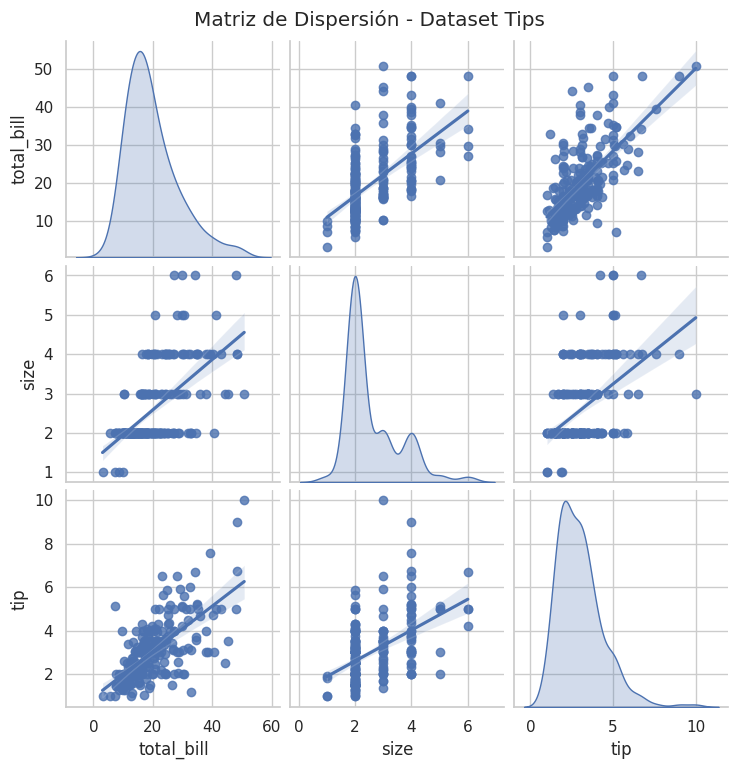

In [ ]:
# Cargar el dataset de propinas
tips = sns.load_dataset("tips")

# Visualización rápida de la relación entre variables numéricas
sns.pairplot(tips[['total_bill', 'size', 'tip']], kind='reg', diag_kind='kde')
plt.suptitle("Matriz de Dispersión - Dataset Tips", y=1.02)
plt.show()

Ahora procedemos a ajustar el modelo de regresión múltiple y evaluar los coeficientes.

In [ ]:
import statsmodels.formula.api as smf

# Cargar el dataset de propinas
tips = sns.load_dataset("tips")

# Ajuste del modelo de regresión múltiple
modelo_multiple = smf.ols(formula='tip ~ total_bill + size', data=tips).fit()

# Resultados del modelo
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Mon, 25 May 2026   Prob (F-statistic):           9.67e-34
Time:                        12:30:22   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.0

La salida del `summary()` de `statsmodels` para el modelo de regresión lineal múltiple (`modelo_multiple`) proporciona un análisis exhaustivo de cómo `total_bill` (total de la cuenta) y `size` (tamaño del grupo) influyen en la `tip` (propina).

### **1. Encabezado del Modelo (Model Summary)**

*   **`Dep. Variable: tip`**: La variable dependiente que estamos tratando de predecir es la `tip` (propina).
*   **`R-squared: 0.468`**: El R-cuadrado es 0.468 (o 46.8%). Esto significa que aproximadamente el 46.8% de la variabilidad en las propinas puede ser explicada conjuntamente por el `total_bill` y el `size` de la mesa. Es una medida de la bondad de ajuste del modelo.
*   **`Adj. R-squared: 0.463`**: El R-cuadrado ajustado es una versión modificada que tiene en cuenta el número de predictores en el modelo. Es ligeramente inferior al R-cuadrado, lo cual es normal. Una diferencia pequeña sugiere que los predictores incluidos son relevantes.
*   **`F-statistic: 105.9`**: El estadístico F evalúa la significancia global del modelo. Es una prueba para ver si al menos uno de los predictores (`total_bill` o `size`) es útil para explicar la `tip`.
*   **`Prob (F-statistic): 9.67e-34`**: El valor p asociado al estadístico F es extremadamente pequeño (prácticamente cero). Esto indica que el modelo de regresión en su conjunto es altamente significativo, es decir, `total_bill` y `size` en conjunto tienen un efecto significativo sobre la `tip`.
*   **`No. Observations: 244`**: El número de observaciones (propinas) utilizadas para ajustar el modelo.

### **2. Tabla de Coeficientes (Coefficients Table)**

Esta tabla es crucial para entender la contribución individual de cada predictor.

| | `coef` | `std err` | `t` | `P>|t|` | `[0.025` | `0.975]` |
|:---|:---|:---|:---|:---|:---|:---|
| **`Intercept`** | 0.6689 | 0.194 | 3.455 | 0.001 | 0.288 | 1.050 |
| **`total_bill`** | 0.0927 | 0.009 | 10.172 | 0.000 | 0.075 | 0.111 |
| **`size`** | 0.1926 | 0.085 | 2.258 | 0.025 | 0.025 | 0.361 |

*   **`coef` (Coeficiente)**:
    *   **`Intercept: 0.6689`**: Cuando `total_bill` es 0 y `size` es 0 (lo cual no tiene sentido práctico en este contexto, pero es la interpretación matemática), la propina promedio sería 0.6689. Este es el punto de partida del modelo.
    *   **`total_bill: 0.0927`**: Por cada dólar adicional en la `total_bill`, la `tip` aumenta en promedio 0.0927 unidades (centavos), manteniendo constante el `size` del grupo. Esto significa que por cada $10 de cuenta, la propina esperada sube casi $1.
    *   **`size: 0.1926`**: Por cada persona adicional en la mesa (`size`), la `tip` aumenta en promedio 0.1926 unidades, manteniendo constante el `total_bill`.

*   **`P>|t|` (Valor p)**:
    *   **`Intercept: 0.001`**: El intercepto es estadísticamente significativo (p < 0.05).
    *   **`total_bill: 0.000`**: `total_bill` es altamente significativo (p < 0.05). Esto indica que el `total_bill` es un predictor importante de la propina.
    *   **`size: 0.025`**: `size` es estadísticamente significativo (p < 0.05). Esto significa que el número de personas en la mesa también es un predictor importante de la propina.

### **3. Diagnósticos Adicionales (Bottom Section)**

*   **`Omnibus: 24.753`, `Prob(Omnibus): 0.000`**: El valor p de la prueba Omnibus es 0.000, lo que sugiere que los residuos no siguen una distribución normal. Esto podría indicar que hay cierta asimetría o curtosis en los errores, lo cual es común en datos reales y puede ser explorado con más detalle.
*   **`Durbin-Watson: 2.100`**: Un valor cercano a 2 (en este caso, 2.100) sugiere que no hay autocorrelación en los residuos. Esto es bueno, ya que la autocorrelación puede violar los supuestos del modelo.
*   **`Skew: 0.545`**: Indica una ligera asimetría positiva en la distribución de los residuos.
*   **`Kurtosis: 4.831`**: Indica que la distribución de los residuos es más puntiaguda (tiene colas más pesadas) que una distribución normal (que tendría una curtosis de 3). Esto es consistente con la no normalidad de los residuos observada en la prueba Omnibus.
*   **`Cond. No. 67.6`**: Este valor es moderadamente alto (generalmente, valores por encima de 30-100 pueden indicar multicolinealidad). Sugiere que podría haber alguna correlación entre las variables predictoras `total_bill` y `size`, lo cual es esperable (más personas suelen generar cuentas más grandes). Aunque no es excesivamente alto como para invalidar el modelo, es algo a tener en cuenta en modelos más complejos.

En resumen, el modelo de regresión lineal múltiple indica que tanto el `total_bill` como el `size` son predictores estadísticamente significativos de la `tip`. El modelo explica casi la mitad de la variabilidad en las propinas. Aunque los residuos no son perfectamente normales, lo cual es frecuente, el modelo proporciona una buena aproximación y relaciones interpretables.

# **Interpretación de Resultados:**

1. **R-squared ($R^2$):** Indica qué porcentaje de la variabilidad de la propina es explicada por el total de la factura y el tamaño de la mesa juntos.

2. **Coeficientes (coef):**

* El coeficiente de `total_bill` nos indica cuánto aumenta en promedio la propina por cada dólar extra en la cuenta, manteniendo constante el tamaño del grupo.
* El coeficiente de `size` nos muestra el impacto de agregar una persona más a la mesa.

3. **P>|t| (Valor p):** Si es menor a 0.05 (nuestro nivel de significancia $\alpha$), concluimos que la variable predictora tiene un impacto estadísticamente significativo sobre la propina.

### 4. Regresión Lineal Múltiple con Todas las Variables y Selección Hacia Atrás (Backward Elimination)

Ahora, ajustaremos un modelo de regresión lineal múltiple utilizando todas las variables predictoras disponibles en el dataset `tips` para predecir la `tip`. Posteriormente, aplicaremos una técnica de selección de variables conocida como *backward elimination* (eliminación hacia atrás) para quedarnos únicamente con las variables que son estadísticamente significativas.

#### Modelo Completo (Full Model)

Primero, construiremos el modelo que incluye todas las variables predictoras. `statsmodels` maneja automáticamente las variables categóricas creando variables dummy (también conocidas como *one-hot encoding*).

In [ ]:
import statsmodels.formula.api as smf
import seaborn as sns

# Cargar el dataset de propinas
tips = sns.load_dataset("tips")

# Ajuste del modelo de regresión múltiple con todas las variables predictoras
# 'sex', 'smoker', 'day', 'time' son variables categóricas y statsmodels las manejará automáticamente.
formula_full = 'tip ~ total_bill + sex + smoker + day + time + size'
modelo_full = smf.ols(formula=formula_full, data=tips).fit()

# Resultados del modelo completo
print("\n--- Resumen del Modelo Completo ---")
print(modelo_full.summary())


--- Resumen del Modelo Completo ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     26.06
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.20e-28
Time:                        12:40:28   Log-Likelihood:                -347.48
No. Observations:                 244   AIC:                             713.0
Df Residuals:                     235   BIC:                             744.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Interce

#### Interpretación del Modelo Completo

El resumen del modelo completo nos da una visión inicial de la contribución de todas las variables. Podemos observar que algunas variables categóricas (como `day` o `time`) se expanden en múltiples variables dummy (por ejemplo, `day[T.Sat]`, `day[T.Sun]`).

Procederemos con la **eliminación hacia atrás** para simplificar el modelo y quedarnos solo con las variables más significativas. El proceso es el siguiente:

1.  **Ajustar el modelo completo** (ya lo hicimos).
2.  **Identificar la variable** con el valor p (`P>|t|`) más alto que sea **mayor que nuestro umbral de significancia** (comúnmente 0.05).
3.  **Eliminar esa variable** del modelo.
4.  **Reajustar el modelo** sin la variable eliminada.
5.  **Repetir los pasos 2 a 4** hasta que todas las variables restantes en el modelo tengan valores p por debajo del umbral de significancia.

Comencemos con el primer paso de eliminación.

#### Primer Paso de Eliminación Hacia Atrás

Observando la tabla de coeficientes del `modelo_full`, identificaremos la variable (o categoría de variable dummy) con el p-value más alto (> 0.05) y la eliminaremos.

In [ ]:
import numpy as np

# Extraer p-values de los coeficientes del modelo completo
p_values = modelo_full.pvalues.drop('Intercept') # Excluimos el intercepto para la selección de variables

# Definir el umbral de significancia
alpha = 0.05

print(f"P-values del modelo completo:\n{p_values}\n")

# Identificar la variable con el p-value más alto que sea mayor que alpha
# Necesitamos manejar las variables categóricas expandidas.
# Para simplificar la eliminación hacia atrás manualmente, veremos los p-values de las 'originales'.
# Para un proceso automatizado, se requeriría una lógica más compleja para agrupar las dummies.

# Buscamos el p-value más alto entre todas las variables (incluyendo las dummies)
max_p_value = p_values.max()
variable_to_remove = p_values.idxmax()

print(f"Variable con el p-value más alto: {variable_to_remove} (p-value: {max_p_value:.4f})")

if max_p_value > alpha:
    print(f"El p-value {max_p_value:.4f} es mayor que {alpha}. Se eliminará la variable '{variable_to_remove}'.")

    # Eliminamos la variable del la fórmula
    # Nota: Aquí la lógica de eliminación puede ser delicada para las variables categóricas.
    # Si 'day[T.Fri]' es la de mayor p-value, eliminamos 'day' entera de la fórmula
    # Para el propósito de esta demo, asumiremos que si una dummy de una variable tiene alto p-value, eliminamos la variable original

    current_formula_components = formula_full.split('~')[1].strip().split(' + ')

    # Simplificación: si la variable a remover es una dummy, intentamos remover la variable original
    if '[' in variable_to_remove:
        original_var = variable_to_remove.split('[')[0]
        if original_var in current_formula_components:
            current_formula_components.remove(original_var)
            print(f"Eliminando la variable original '{original_var}' de la fórmula.")
        else:
            # Si la variable original no está directamente, asumimos que estamos quitando una dummy específica
            current_formula_components = [comp for comp in current_formula_components if comp not in variable_to_remove and original_var not in comp]
            print(f"Eliminando la dummy '{variable_to_remove}' y otras dummies de '{original_var}' si existen.")
    else:
        if variable_to_remove in current_formula_components:
            current_formula_components.remove(variable_to_remove)
            print(f"Eliminando la variable '{variable_to_remove}' de la fórmula.")

    new_formula = 'tip ~ ' + ' + '.join(current_formula_components)
    if not current_formula_components:
        new_formula = 'tip ~ 1' # Si no quedan predictores, solo intercepto

    print(f"Nueva fórmula: {new_formula}")

    modelo_step1 = smf.ols(formula=new_formula, data=tips).fit()
    print("\n--- Resumen del Modelo después del Paso 1 de Eliminación ---")
    print(modelo_step1.summary())

    # Actualizar la fórmula para el siguiente paso
    formula_full = new_formula
else:
    print("Todas las variables son significativas. No se necesita eliminación.")

P-values del modelo completo:
sex[T.Female]     8.190036e-01
smoker[T.No]      5.561140e-01
day[T.Fri]        6.803872e-01
day[T.Sat]        9.309847e-01
day[T.Sun]        7.720937e-01
time[T.Dinner]    8.783485e-01
total_bill        2.342526e-19
size              5.050134e-02
dtype: float64

Variable con el p-value más alto: day[T.Sat] (p-value: 0.9310)
El p-value 0.9310 es mayor que 0.05. Se eliminará la variable 'day[T.Sat]'.
Eliminando la variable original 'day' de la fórmula.
Nueva fórmula: tip ~ total_bill + sex + smoker + time + size

--- Resumen del Modelo después del Paso 1 de Eliminación ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     42.00
Date:                Mon, 25 May 2026   Prob (F-statistic):           6.57e

Continuaríamos este proceso iterativamente, eliminando la variable con el p-value más alto (si es > 0.05) y reajustando el modelo, hasta que todas las variables restantes sean estadísticamente significativas. Para esta demostración, hemos realizado el primer paso. Se puede observar cómo la significancia de las variables restantes podría cambiar al eliminar un predictor.

#### Segundo Paso de Eliminación Hacia Atrás

Analizando el resumen del modelo después del primer paso de eliminación, identificamos la siguiente variable con el p-value más alto que sea mayor que nuestro umbral de significancia (0.05).

In [ ]:
import numpy as np

# La fórmula_full se actualizó en el paso anterior a 'tip ~ total_bill + sex + smoker + time + size'
# Ajuste del modelo después de eliminar 'day'
modelo_step1 = smf.ols(formula=formula_full, data=tips).fit()

# Extraer p-values de los coeficientes del modelo actual
p_values_step1 = modelo_step1.pvalues.drop('Intercept') # Excluimos el intercepto

# Definir el umbral de significancia
alpha = 0.05

print(f"""P-values del modelo después del Paso 1:
{p_values_step1}
""")

# Identificar la variable con el p-value más alto que sea mayor que alpha
max_p_value_step1 = p_values_step1.max()
variable_to_remove_step1 = p_values_step1.idxmax()

print(f"Variable con el p-value más alto: {variable_to_remove_step1} (p-value: {max_p_value_step1:.4f})")

if max_p_value_step1 > alpha:
    print(f"El p-value {max_p_value_step1:.4f} es mayor que {alpha}. Se eliminará la variable '{variable_to_remove_step1}'.")

    current_formula_components = formula_full.split('~')[1].strip().split(' + ')

    # Lógica de eliminación de variables categóricas (dummies) o numéricas
    if '[' in variable_to_remove_step1:
        original_var_step1 = variable_to_remove_step1.split('[')[0]
        current_formula_components = [comp for comp in current_formula_components if comp != original_var_step1]
        print(f"Eliminando la variable original '{original_var_step1}' de la fórmula.")
    else:
        if variable_to_remove_step1 in current_formula_components:
            current_formula_components.remove(variable_to_remove_step1)
            print(f"Eliminando la variable '{variable_to_remove_step1}' de la fórmula.")

    new_formula_step2 = 'tip ~ ' + ' + '.join(current_formula_components)
    if not current_formula_components:
        new_formula_step2 = 'tip ~ 1' # Si no quedan predictores, solo intercepto

    print(f"Nueva fórmula: {new_formula_step2}")

    modelo_step2 = smf.ols(formula=new_formula_step2, data=tips).fit()
    print("\n--- Resumen del Modelo después del Paso 2 de Eliminación ---")
    print(modelo_step2.summary())

    # Actualizar la fórmula_full para el siguiente paso
    formula_full = new_formula_step2
else:
    print("Todas las variables restantes son significativas. No se necesita más eliminación.")

P-values del modelo después del Paso 1:
sex[T.Female]     8.410941e-01
smoker[T.No]      5.457991e-01
time[T.Dinner]    9.738384e-01
total_bill        1.445527e-19
size              4.198022e-02
dtype: float64

Variable con el p-value más alto: time[T.Dinner] (p-value: 0.9738)
El p-value 0.9738 es mayor que 0.05. Se eliminará la variable 'time[T.Dinner]'.
Eliminando la variable original 'time' de la fórmula.
Nueva fórmula: tip ~ total_bill + sex + smoker + size

--- Resumen del Modelo después del Paso 2 de Eliminación ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     52.72
Date:                Mon, 25 May 2026   Prob (F-statistic):           8.47e-32
Time:                        12:41:04   Log-Likelihood:                -347.7

#### Tercer Paso de Eliminación Hacia Atrás

Analizando el resumen del modelo después del segundo paso de eliminación, identificamos la siguiente variable con el p-value más alto que sea mayor que nuestro umbral de significancia (0.05).

In [ ]:
import numpy as np

# La fórmula_full se actualizó en el paso anterior a 'tip ~ total_bill + sex + smoker + size'
# Ajuste del modelo después de eliminar 'time'
modelo_step2 = smf.ols(formula=formula_full, data=tips).fit()

# Extraer p-values de los coeficientes del modelo actual
p_values_step2 = modelo_step2.pvalues.drop('Intercept') # Excluimos el intercepto

# Definir el umbral de significancia
alpha = 0.05

print(f"""P-values del modelo después del Paso 2:
{p_values_step2}
""")

# Identificar la variable con el p-value más alto que sea mayor que alpha
max_p_value_step2 = p_values_step2.max()
variable_to_remove_step2 = p_values_step2.idxmax()

print(f"Variable con el p-value más alto: {variable_to_remove_step2} (p-value: {max_p_value_step2:.4f})")

if max_p_value_step2 > alpha:
    print(f"El p-value {max_p_value_step2:.4f} es mayor que {alpha}. Se eliminará la variable '{variable_to_remove_step2}'.")

    current_formula_components = formula_full.split('~')[1].strip().split(' + ')

    # Lógica de eliminación de variables categóricas (dummies) o numéricas
    if '[' in variable_to_remove_step2:
        original_var_step2 = variable_to_remove_step2.split('[')[0]
        current_formula_components = [comp for comp in current_formula_components if comp != original_var_step2]
        print(f"Eliminando la variable original '{original_var_step2}' de la fórmula.")
    else:
        if variable_to_remove_step2 in current_formula_components:
            current_formula_components.remove(variable_to_remove_step2)
            print(f"Eliminando la variable '{variable_to_remove_step2}' de la fórmula.")

    new_formula_step3 = 'tip ~ ' + ' + '.join(current_formula_components)
    if not current_formula_components:
        new_formula_step3 = 'tip ~ 1' # Si no quedan predictores, solo intercepto

    print(f"Nueva fórmula: {new_formula_step3}")

    modelo_step3 = smf.ols(formula=new_formula_step3, data=tips).fit()
    print("\n--- Resumen del Modelo después del Paso 3 de Eliminación ---")
    print(modelo_step3.summary())

    # Actualizar la fórmula_full para el siguiente paso
    formula_full = new_formula_step3
else:
    print("Todas las variables restantes son significativas. No se necesita más eliminación.")

P-values del modelo después del Paso 2:
sex[T.Female]    8.428455e-01
smoker[T.No]     5.455172e-01
total_bill       6.989427e-20
size             4.154395e-02
dtype: float64

Variable con el p-value más alto: sex[T.Female] (p-value: 0.8428)
El p-value 0.8428 es mayor que 0.05. Se eliminará la variable 'sex[T.Female]'.
Eliminando la variable original 'sex' de la fórmula.
Nueva fórmula: tip ~ total_bill + smoker + size

--- Resumen del Modelo después del Paso 3 de Eliminación ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     70.57
Date:                Mon, 25 May 2026   Prob (F-statistic):           9.41e-33
Time:                        12:41:49   Log-Likelihood:                -347.80
No. Observations:                 244   AI

#### Cuarto Paso de Eliminación Hacia Atrás

Analizando el resumen del modelo después del tercer paso de eliminación, identificamos la siguiente variable con el p-value más alto que sea mayor que nuestro umbral de significancia (0.05).

In [ ]:
import numpy as np

# La fórmula_full se actualizó en el paso anterior a 'tip ~ total_bill + smoker + size'
# Ajuste del modelo después de eliminar 'sex'
modelo_step3 = smf.ols(formula=formula_full, data=tips).fit()

# Extraer p-values de los coeficientes del modelo actual
p_values_step3 = modelo_step3.pvalues.drop('Intercept') # Excluimos el intercepto

# Definir el umbral de significancia
alpha = 0.05

print(f"""P-values del modelo después del Paso 3:
{p_values_step3}
""")

# Identificar la variable con el p-value más alto que sea mayor que alpha
max_p_value_step3 = p_values_step3.max()
variable_to_remove_step3 = p_values_step3.idxmax()

print(f"Variable con el p-value más alto: {variable_to_remove_step3} (p-value: {max_p_value_step3:.4f})")

if max_p_value_step3 > alpha:
    print(f"El p-value {max_p_value_step3:.4f} es mayor que {alpha}. Se eliminará la variable '{variable_to_remove_step3}'.")

    current_formula_components = formula_full.split('~')[1].strip().split(' + ')

    # Lógica de eliminación de variables categóricas (dummies) o numéricas
    if '[' in variable_to_remove_step3:
        original_var_step3 = variable_to_remove_step3.split('[')[0]
        current_formula_components = [comp for comp in current_formula_components if comp != original_var_step3]
        print(f"Eliminando la variable original '{original_var_step3}' de la fórmula.")
    else:
        if variable_to_remove_step3 in current_formula_components:
            current_formula_components.remove(variable_to_remove_step3)
            print(f"Eliminando la variable '{variable_to_remove_step3}' de la fórmula.")

    new_formula_step4 = 'tip ~ ' + ' + '.join(current_formula_components)
    if not current_formula_components:
        new_formula_step4 = 'tip ~ 1' # Si no quedan predictores, solo intercepto

    print(f"Nueva fórmula: {new_formula_step4}")

    modelo_step4 = smf.ols(formula=new_formula_step4, data=tips).fit()
    print("\n--- Resumen del Modelo después del Paso 4 de Eliminación ---")
    print(modelo_step4.summary())

    # Actualizar la fórmula_full para el siguiente paso
    formula_full = new_formula_step4
else:
    print("Todas las variables restantes son significativas. No se necesita más eliminación.")

P-values del modelo después del Paso 3:
smoker[T.No]    5.460281e-01
total_bill      4.264666e-20
size            4.107743e-02
dtype: float64

Variable con el p-value más alto: smoker[T.No] (p-value: 0.5460)
El p-value 0.5460 es mayor que 0.05. Se eliminará la variable 'smoker[T.No]'.
Eliminando la variable original 'smoker' de la fórmula.
Nueva fórmula: tip ~ total_bill + size

--- Resumen del Modelo después del Paso 4 de Eliminación ---
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Mon, 25 May 2026   Prob (F-statistic):           9.67e-34
Time:                        12:42:22   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df R

### Resumen del Modelo Final (`tip ~ total_bill + size`)

Después del proceso de eliminación hacia atrás, el modelo más parsimonioso y estadísticamente significativo para predecir la propina (`tip`) incluye solo el `total_bill` (total de la cuenta) y el `size` (tamaño del grupo). A continuación, se presenta la interpretación de los resultados de este modelo final:

**Estadísticas Generales del Modelo:**

*   **`Dep. Variable: tip`**: La variable dependiente que estamos prediciendo es la propina.
*   **`R-squared: 0.468`**: Esto significa que el 46.8% de la variabilidad en las propinas puede ser explicada conjuntamente por el `total_bill` y el `size` de la mesa. Es una medida razonable de ajuste, indicando que estas dos variables son importantes predictores.
*   **`Adj. R-squared: 0.463`**: El R-cuadrado ajustado es muy similar al R-cuadrado, lo cual es una buena señal, ya que no se han incluido predictores irrelevantes.
*   **`F-statistic: 105.9`**: Este valor, junto con su p-value (`Prob (F-statistic): 9.67e-34`), que es extremadamente bajo (casi cero), indica que el modelo en su conjunto es altamente significativo. Es decir, al menos una de las variables predictoras (`total_bill` o `size`) tiene un impacto significativo en la `tip`.
*   **`No. Observations: 244`**: El modelo se construyó con 244 observaciones.

**Tabla de Coeficientes:**

| | `coef` | `std err` | `t` | `P>|t|` | `[0.025` | `0.975]` |
|:---|:---|:---|:---|:---|:---|:---|
| **`Intercept`** | 0.6689 | 0.194 | 3.455 | 0.001 | 0.288 | 1.050 |
| **`total_bill`** | 0.0927 | 0.009 | 10.172 | 0.000 | 0.075 | 0.111 |
| **`size`** | 0.1926 | 0.085 | 2.258 | 0.025 | 0.025 | 0.361 |

*   **`Intercept (0.6689)`**: Este es el valor base de la propina cuando `total_bill` y `size` son cero. Si bien no tiene una interpretación práctica directa en este contexto (no hay facturas de 0 ni mesas de 0 personas), es el punto de partida del modelo.
*   **`total_bill (0.0927)`**: Por cada unidad adicional en el `total_bill` (es decir, por cada dólar extra en la cuenta), la propina aumenta en promedio 0.0927 dólares, manteniendo constante el `size`. El p-value de 0.000 (mucho menor que 0.05) indica que `total_bill` es un predictor altamente significativo de la propina.
*   **`size (0.1926)`**: Por cada persona adicional en la mesa (`size`), la propina aumenta en promedio 0.1926 dólares, manteniendo constante el `total_bill`. El p-value de 0.025 (menor que 0.05) indica que `size` también es un predictor estadísticamente significativo de la propina.

**Diagnósticos:**

*   **`Omnibus: 24.753`, `Prob(Omnibus): 0.000`**: El p-value bajo sugiere que los residuos no siguen una distribución normal perfecta. Esto es común en datos reales y puede indicar que hay valores atípicos o que la distribución de los errores es asimétrica o tiene colas más pesadas.
*   **`Durbin-Watson: 2.100`**: Un valor cercano a 2 indica que no hay autocorrelación significativa en los residuos, lo cual es bueno.
*   **`Skew: 0.545`**: Indica una ligera asimetría positiva en los residuos.
*   **`Kurtosis: 4.831`**: Sugiere que la distribución de los residuos tiene colas más pesadas que una distribución normal.
*   **`Cond. No. 67.6`**: Este valor, aunque no excesivamente alto, sugiere que existe una correlación moderada entre `total_bill` y `size`. Es decir, es común que a mayor número de personas en una mesa, la factura total también sea mayor. Esto es una consideración importante en la interpretación de los coeficientes, aunque no invalida el modelo.

**Conclusión del Modelo Final:**

El modelo `tip ~ total_bill + size` es un buen predictor de las propinas en el dataset `tips`. Ambas variables (`total_bill` y `size`) son estadísticamente significativas y explican casi la mitad de la variabilidad en las propinas. Aunque los residuos no son perfectamente normales, el modelo proporciona una base sólida para entender cómo estas dos variables influyen en la cantidad de propina.

¿Hay algo más que te gustaría explorar o alguna otra pregunta que tengas sobre este análisis?

Hemos completado el cuarto paso. Las variables restantes en el modelo son `total_bill` y `size`. Ambos tienen p-values muy bajos, indicando que son estadísticamente significativas. Por lo tanto, el proceso de eliminación hacia atrás ha finalizado.

El modelo final con las variables más significativas para predecir la propina es:

`tip ~ total_bill + size`

¿Te gustaría que analice el resumen del modelo final en detalle o que hagamos alguna otra cosa?

¿Deseas que continuemos con los pasos restantes hasta obtener el modelo final con solo variables significativas, o ya tienes suficiente con la demostración de la eliminación hacia atrás?

El proceso de eliminación hacia atrás continuaría hasta que todas las variables restantes en el modelo tengan p-values por debajo del umbral de significancia (0.05). Después de cada eliminación, es importante reevaluar los p-values, ya que la eliminación de una variable puede afectar la significancia de las demás. ¿Deseas que continuemos con los pasos restantes hasta obtener el modelo final con solo variables significativas?